<a href="https://colab.research.google.com/github/Bubukisapisa/ML_education/blob/main/%22HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [176]:
import importlib
import os
import numpy as np
import pandas as pd
import process_bank_churn as pp
from sklearn.tree import DecisionTreeClassifier
importlib.reload(pp)
from sklearn.metrics import roc_auc_score

In [177]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [178]:
prep_df = pd.read_csv('drive/MyDrive/ML for people/train.csv')

In [179]:
data = pp.preprocess_data(prep_df)

/content/process_bank_churn.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_new['Gender'] = df_new['Gender'].replace({'Male': 1, 'Female': 0})


In [180]:
?pp.preprocess_data

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [181]:
model = DecisionTreeClassifier(random_state=42)
model.fit(data['train_x'], data['train_y'])

DecisionTreeClassifier(random_state=42)

In [182]:
y_proba = model.predict_proba(data['train_x'])[:, 1]
auc_train = roc_auc_score(data['train_y'], y_proba)

y_proba_val = model.predict_proba(data['val_x'])[:, 1]
auc_val = roc_auc_score(data['val_y'], y_proba_val)

display(auc_train, auc_val)

np.float64(1.0)

np.float64(0.764267096508677)

модель перетренована - на тренувальних даних маєм auroc 1, на валідаційних 0.77

In [183]:
model.tree_.max_depth

23

In [184]:
model_2 = DecisionTreeClassifier(max_depth=2, random_state=42)
model_2.fit(data['train_x'], data['train_y'])

DecisionTreeClassifier(max_depth=2, random_state=42)

In [185]:
importance_df = pd.DataFrame({
    'feature': data['train_x'].columns,
    'importance': model_2.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(2)

,feature,importance
4,Age,0.714962
7,NumOfProducts,0.285038


Найвливовішими є вік і кількість продуктів

In [186]:
importance_df = pd.DataFrame({
    'feature': data['train_x'].columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
4,Age,0.343930
7,NumOfProducts,0.168379
10,EstimatedSalary,0.077997
2,CreditScore,0.076725
0,id,0.073890
1,CustomerId,0.072234
6,Balance,0.068455
5,Tenure,0.034722
9,IsActiveMember,0.033352
3,Gender,0.015279


Здається серед 10 найвпливовіших 3 останні дуже слабко впливають (Гендер, локація Німеччина, наявність кред карти)

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [187]:
model_exp = DecisionTreeClassifier(random_state=42, max_depth = 5)
model_exp.fit(data['train_x'], data['train_y'])

y_proba = model_exp.predict_proba(data['train_x'])[:, 1]
auc_train = roc_auc_score(data['train_y'], y_proba)

y_proba_val = model_exp.predict_proba(data['val_x'])[:, 1]
auc_val = roc_auc_score(data['val_y'], y_proba_val)

display(auc_train, auc_val)


np.float64(0.9257663544386708)

np.float64(0.921863639481446)

Спробував використати параметри max_depth, max_leaf_nodes, ccp_alpha. Гарну точність показує модель з параметром max_depth = 5, або max_leaf_nodes = 30. Залишив варіант з максимальною глибиною так як вважаю (аде це субєктивно, не перевіряв) що легше буде аналізувати дерево з глибиною 5 (можна ще розглянути варіант глибини в 4) аніж 30 листів.

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [188]:
def max_depth(n, data):
  data = data
  output = {
      'train': [],
      'validation': []
  }
  for i in range(n):
    iter = i+1
    model = DecisionTreeClassifier(random_state=42, max_depth = iter)
    model.fit(data['train_x'], data['train_y'])

    y_proba = model.predict_proba(data['train_x'])[:, 1]
    auc_train = roc_auc_score(data['train_y'], y_proba)

    y_proba_val = model.predict_proba(data['val_x'])[:, 1]
    auc_val = roc_auc_score(data['val_y'], y_proba_val)

    output['train'].append(auc_train)
    output['validation'].append(auc_val)
  return output

In [189]:
test = max_depth(20, data)

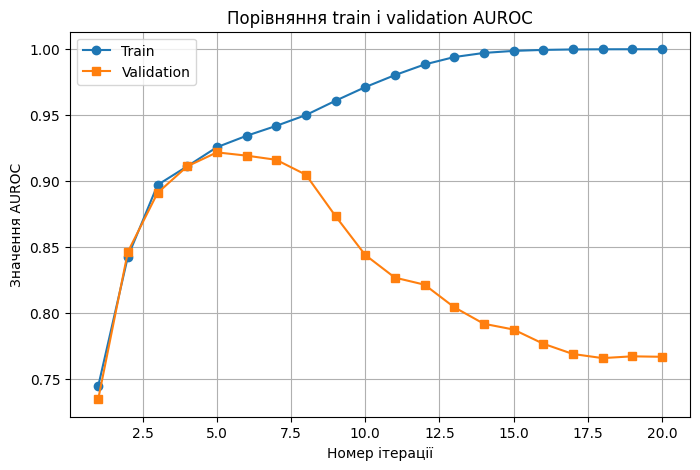

In [190]:
import matplotlib.pyplot as plt

list1 = test['train']
list2 = test['validation']

x = range(1, len(list1) + 1)

plt.figure(figsize=(8, 5))
plt.plot(x, list1, marker='o', label='Train')
plt.plot(x, list2, marker='s', label='Validation')

# Підписи осей і заголовок
plt.xlabel('Номер ітерації')
plt.ylabel('Значення AUROC')
plt.title('Порівняння train i validation AUROC')

# Відображення легенди та сітки
plt.legend()
plt.grid(True)
plt.show()

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [191]:
test_df = pd.read_csv('drive/MyDrive/ML for people/test.csv')
test_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [192]:
test_df_prep = pp.preprocess_new_data(test_df, scaler=data['scaler'], encoder=data['encoder'])

/content/process_bank_churn.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_new['Gender'] = df_new['Gender'].replace({'Male': 1, 'Female': 0})


In [193]:
test_df_prep.head()

,id,CustomerId,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,15000,15594796.0,0.365155,1.0,0.214286,0.2,0.696265,1.0,1.0,1.0,0.789477,0.0,1.0,0.0
1,15001,15642821.0,0.286396,1.0,0.375000,0.5,0.000000,2.0,1.0,1.0,0.337131,1.0,0.0,0.0
2,15002,15716284.0,0.656325,1.0,0.446429,0.8,0.000000,2.0,1.0,0.0,0.783859,1.0,0.0,0.0
3,15003,15785078.0,0.682578,1.0,0.482143,0.3,0.000000,1.0,1.0,1.0,0.834571,0.0,0.0,1.0
4,15004,15662955.0,0.384248,1.0,0.446429,0.8,0.000000,2.0,1.0,1.0,0.718421,0.0,0.0,1.0


In [194]:
model_fin = DecisionTreeClassifier(random_state=42, max_depth = 5)
model_fin.fit(data['train_x'], data['train_y'])

DecisionTreeClassifier(max_depth=5, random_state=42)

In [195]:
y_proba = model_fin.predict_proba(test_df_prep)[:, 1]
y_proba

array([0.23791103, 0.02761341, 0.02761341, ..., 0.00892374, 0.04173355,
       0.20459082])

In [196]:
test_df_prep['Exited'] = y_proba

In [197]:
sample_sub = pd.read_csv('drive/MyDrive/ML for people/sample_submission.csv')

In [198]:
sample_sub = sample_sub.merge(test_df_prep[["id", "Exited"]], on="id", how="left", suffixes=("", "_new"))
sample_sub["Exited"] = sample_sub["Exited_new"]
sample_sub = sample_sub.drop(columns="Exited_new")

sample_sub.head()

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.761702
4,15004,0.027613


In [199]:
sample_sub.to_csv("submission_log_reg.csv", index=False, encoding="utf-8")